# Data

> Core data structures and classes for biomedical imaging, integrating MONAI's MetaTensors with fastai's transform pipelines.

The `bioMONAI.data.core` module introduces specialized base classes (`BioDataClass`, `BioImageBase`, etc.) to represent various bioimaging data structures. By addressing metaclass conflicts and providing built-in visualization utilities, these classes facilitate the seamless integration of complex multidimensional medical images into standard machine learning workflows.

### Included Classes
* **`MetaResolver`**: A custom metaclass designed to elegantly resolve compatibility conflicts between fastai's foundations and MONAI's `MetaTensor`.
* **`BioDataClass`**: The foundational base class that provides the core fastai/MONAI integration for all subsequent data structures.
* **`BioImageBase` & `BioImage`**: Core structures for unified loading and visualization of standard 2D/3D images.
* **`BioVolume`**: Specialized handling and grid visualization for 3D Z-stacks (`CZYX`).
* **`BioMIP`**: On-the-fly Maximum Intensity Projections for flattening thick volumetric data.
* **`BioVideo`**: Temporal data support (`CTYX`) for live-cell and dynamic imaging.
* **`BioMultiChannel`**: Composited and interleaved visualization for multi-channel microscopy.
* **`BioLabel`**: Categorical label encoding and vocabulary management.

In [ ]:
#| default_exp data.core

In [ ]:
#| hide
from nbdev.showdoc import *
from fastcore.test import *

from torch import Size as _Size, rand as torchrand, ones as torchones, arange as torcharange

import matplotlib.pyplot as plt

import warnings

In [ ]:
#| export

# =================================
# Standard library
# =================================
from plum import dispatch

# =================================
# fastai
# =================================
from fastai.torch_core import TensorImage, TensorCategory, TensorMultiCategory
from fastai.vision.all import TransformBlock, Categorize

# =================================
# bioMONAI
# =================================
from bioMONAI.utils import *
from bioMONAI.io import image_reader, image_reader_dict
from bioMONAI.visualize import show_biodata, show_multichannel

# =================================
# fasttransform patch
# =================================
import fasttransform

_original_repr = fasttransform.transform.Transform.__repr__

def _safe_repr(self):
    try:
        return _original_repr(self)
    except AttributeError as e:
        if "'_BoundFunction' object has no attribute 'methods'" in str(e):
            return f"{self.__class__.__name__}(...)"
        raise

fasttransform.transform.Transform.__repr__ = _safe_repr

## Data Types
> Specialized classes to represent various bioimaging data structures, facilitating seamless integration with both fastai and MONAI machine learning workflows. 

* **`MetaResolver`**: A custom metaclass designed to resolve conflicts between PyTorch tensor bases and fastai's custom tensor types, enabling safe multiple inheritance for our core medical data structures.

In [ ]:
#| export

class MetaResolver(type(torchTensor), metaclass=BypassNewMeta):
    """
    The `MetaResolver` class addresses metaclass conflicts, ensuring compatibility across different data structures. This is particularly useful when integrating with libraries that have specific metaclass requirements.
    """
    pass
    

In [ ]:
show_doc(MetaResolver)

---

[source](https://github.com/deepCLEM/bioMONAI/blob/main/bioMONAI/data/core.py#L46){target="_blank" style="float:right; font-size:smaller"}

### MetaResolver

```python

def MetaResolver(
    args:VAR_POSITIONAL, kwargs:VAR_KEYWORD
):


```

*The `MetaResolver` class addresses metaclass conflicts, ensuring compatibility across different data structures. This is particularly useful when integrating with libraries that have specific metaclass requirements.*

#### Example: Using MetaResolver to create a custom tensor class without metaclass conflicts


In [ ]:
class CustomBioTensor(TensorImage, metaclass=MetaResolver):
    """A custom tensor class that safely inherits from fastai's TensorImage."""
    pass

# Initialize our custom tensor
my_tensor = CustomBioTensor([1.0, 2.0, 3.0])
print(f"Type: {type(my_tensor).__name__}")
print(f"Is PyTorch Tensor? {isinstance(my_tensor, torchTensor)}")

Type: CustomBioTensor
Is PyTorch Tensor? True


In [ ]:
#| hide

def test_metaresolver():
    # Test that MetaResolver allows successful class creation and tensor instantiation
    class DummyTensor(torchTensor, metaclass=MetaResolver):
        pass
    
    t = DummyTensor([1.0, 2.0, 3.0])
    test_eq(isinstance(t, torchTensor), True)
    test_eq(t.shape, _Size([3]))
    
    return "MetaResolver tests passed"

test_eq(test_metaresolver(), "MetaResolver tests passed")

### Base Data Classes
> `BioDataClass` acts as the foundational tensor class for all bioMONAI data types. Inheriting from MONAI's `MetaTensor`, it seamlessly carries complex medical metadata while behaving exactly like a standard PyTorch Tensor.

* **Metadata tracking:** Carries affine matrices, spatial shapes, and patient data through the pipeline via the `.meta` dictionary.
* **fastai integration:** Includes built-in methods (like `get_datablock`) to easily hook into fastai's `DataBlock` API.
* **Flexible instantiation:** Can be initialized directly, from standard PyTorch Tensors (`from_tensor`), or from existing MONAI MetaTensors (`from_metatensor`).

In [ ]:
#| export
class BioDataClass(MetaTensor):
    """
    Base class for bioMONAI data.
    """

    _transforms = None
    _keys = []

    # --------------------------------------------------
    # BASIC CONSTRUCTORS
    # --------------------------------------------------
    @classmethod
    def from_tensor(cls, x: torchTensor, meta: dict | None = None):
        return cls(x=x, meta=meta or {})
    
    @classmethod
    def from_metatensor(cls, x: MetaTensor):
        return cls(x=x.data, meta=x.meta)
    
    # --------------------------------------------------
    # TRANSFORMS
    # --------------------------------------------------
    @classmethod
    def set_transforms(cls, transforms):
        cls._transforms = transforms
    
    
    # --------------------------------------------------
    # LOADING
    # --------------------------------------------------
    @classmethod
    def from_source(cls, x, **kwargs):
        raise NotImplementedError("Subclasses must implement the `create` method to define how to instantiate from raw data.")
    
    @classmethod
    def from_dict(cls, x:dict, keys:str|Iterable[str]=None, **kwargs):
        raise NotImplementedError("Subclasses must implement the `create` method to define how to instantiate from raw data.")
    
    # --------------------------------------------------
    # CREATE DATABLOCK (fastai integration)
    # --------------------------------------------------
    @classmethod
    def get_datablock(cls):
        return TransformBlock(type_tfms=[cls.from_source])

    # --------------------------------------------------
    # REPR
    # --------------------------------------------------
    def __repr__(self) -> str:
        return f"{self.__class__.__name__}{self.as_tensor().__repr__()[6:]}"

In [ ]:
show_doc(BioDataClass)

---

[source](https://github.com/deepCLEM/bioMONAI/blob/main/bioMONAI/data/core.py#L54){target="_blank" style="float:right; font-size:smaller"}

### BioDataClass

```python

def BioDataClass(
    x, affine:torch.Tensor | None=None, meta:dict | None=None, applied_operations:list | None=None,
    _args:VAR_POSITIONAL, _kwargs:VAR_KEYWORD
)->None:


```

*Base class for bioMONAI data.*

#### Example: Creating a BioDataClass from standard tensors and MetaTensors


BioDataClass shape: torch.Size([10, 10]) | Metadata: {'patient_id': '12345', 'modality': 'MRI', affine: tensor([[1., 0., 0., 0.],
        [0., 1., 0., 0.],
        [0., 0., 1., 0.],
        [0., 0., 0., 1.]], dtype=torch.float64), space: RAS}
Converted from MetaTensor: BioDataClass


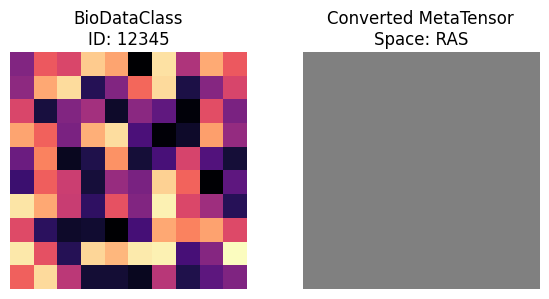

In [ ]:
# 1. Initialize directly from a standard PyTorch Tensor with custom metadata
# We use a 2D tensor to simulate a small image patch
base_tensor = torchrand((10, 10))
bio_data = BioDataClass.from_tensor(base_tensor, meta={"patient_id": "12345", "modality": "MRI"})
print(f"BioDataClass shape: {bio_data.shape} | Metadata: {bio_data.meta}")

# 2. Convert an existing MONAI MetaTensor into a BioDataClass
mt = MetaTensor(x=torchones(5, 5), meta={"space": "RAS"})
bio_from_mt = BioDataClass.from_metatensor(mt)
print(f"Converted from MetaTensor: {type(bio_from_mt).__name__}")

# --- Visualization ---
fig, axes = plt.subplots(1, 2, figsize=(6, 3))

# Plot the BioDataClass tensor
axes[0].imshow(bio_data.numpy(), cmap='magma')
axes[0].set_title(f"BioDataClass\nID: {bio_data.meta['patient_id']}")
axes[0].axis('off')

# Plot the converted MetaTensor
axes[1].imshow(bio_from_mt.numpy(), cmap='gray', vmin=0, vmax=2)
axes[1].set_title(f"Converted MetaTensor\nSpace: {bio_from_mt.meta['space']}")
axes[1].axis('off')

plt.tight_layout()
plt.show()

In [ ]:
#| hide

def test_biodataclass():
    # Test as_subclass casting
    t_sub = torchTensor([1, 2, 3]).as_subclass(BioDataClass)
    test_eq(isinstance(t_sub, BioDataClass), True)
    
    # Test from_metatensor metadata preservation
    mt = MetaTensor(x=[1, 2, 3], meta={"a": 1})
    bdc_mt = BioDataClass.from_metatensor(mt)
    test_eq(bdc_mt.meta["a"], 1)
    
    # Test internal representations and empty initialization
    empty_bdc = BioDataClass([])
    test_eq(empty_bdc.as_tensor().shape, _Size([0]))
    
    # Test custom __repr__ formatting
    repr_str = BioDataClass([1, 2, 3]).__repr__()
    test_eq(repr_str.startswith("BioDataClass"), True)

    return "BioDataClass tests passed"

test_eq(test_biodataclass(), "BioDataClass tests passed")

#### `BioDataClass` Class Attributes & Parameter Reference

| Method | Parameters | Description |
| :--- | :--- | :--- |
| **`from_tensor`** | `x: torch.Tensor`, `meta: dict \| None` | Creates a `BioDataClass` instance from a standard PyTorch tensor and an optional metadata dictionary. |
| **`from_metatensor`** | `x: MetaTensor` | Converts an existing MONAI `MetaTensor` directly into a `BioDataClass`, preserving all metadata. |
| **`set_transforms`** | `transforms` | Class method to set default transforms applied to this data type. |
| **`get_datablock`** | *None* | Returns a fastai `TransformBlock` configured to load this specific data type. |

### Images
> `BioImageBase` acts as the core base class for biomedical images within bioMONAI. It combines the functionality of PyTorch tensors, MONAI's `MetaTensor`, and fastai's visualization utilities (`TensorImage`).

* **Unified Loading:** Seamlessly loads multidimensional image data directly from raw file paths (`from_source`) or dictionaries (`from_dict`).
* **Metadata & ROI:** Manipulates image metadata and extracts Regions of Interest (ROI) via index dictionaries on the fly.
* **Native Visualization:** Includes a built-in `.show()` method to visually render both 2D slices and 3D volumetric grids directly in Jupyter notebooks.

> **Note:** Internal pure loaders (`get_loader`, `get_dict_loader`) return standard MONAI `MetaTensor` objects for maximum compatibility. High-level methods like `from_source` and `from_dict` wrap these outputs directly into `BioImageBase` instances so you can immediately use fastai's `.show()` method.

In [ ]:
#| export
class BioImageBase(BioDataClass, TensorImage, metaclass=MetaResolver):
    """
    Base class for bioimaging data.

    Provides:
    - MetaTensor integration
    - visualization utilities
    - lightweight tensor wrapper

    """

    _bypass_type = torchTensor
    _show_args = {"cmap": "gray"}
    _channels = "CZYX"
    _output = 'metatensor'
    _transforms = None
    _keys = ['image']

    # --------------------------------------------------
    # LOADING
    # --------------------------------------------------
    @classmethod
    def from_source(cls, x, **kwargs):
        metatensor = cls.get_loader(**kwargs)(x)
        return cls(metatensor.data, meta=metatensor.meta)
    
    @classmethod
    def from_dict(cls, x:dict, keys:str|Iterable[str]=None, **kwargs):
        if keys is None:
            keys = []

        metatensor_dict = cls.get_dict_loader(keys=keys, **kwargs)(x)

        if isinstance(keys, str):
            keys = [keys]

        for key in keys:
            if key in metatensor_dict:
                x = metatensor_dict[key]
                metatensor_dict[key] = cls(x.data, meta=x.meta)

        return metatensor_dict
    
    # --------------------------------------------------
    # MONAI INTEGRATION
    # --------------------------------------------------
    @classmethod
    def get_loader(cls,**kwargs) -> Callable:
        def _load(x):
            if isinstance(x, torchTensor):
                return cls.from_tensor(x)

            local_kwargs = dict(kwargs)
            local_kwargs.setdefault("output", cls._output)
            local_kwargs.setdefault("channels", cls._channels)
            local_kwargs.setdefault("transforms", cls._transforms)

            return image_reader(
                x,
                **local_kwargs,
            )

        return _load

    @classmethod
    def get_dict_loader(cls, **kwargs) -> Callable:
        def _load_dict(data: dict):

            local_kwargs = dict(kwargs)
            local_kwargs.setdefault("keys", cls._keys)
            local_kwargs.setdefault("output", cls._output)
            local_kwargs.setdefault("channels", cls._channels)
            local_kwargs.setdefault("transforms", cls._transforms)

            return image_reader_dict(
                data,
                **local_kwargs,
            )

        return _load_dict
    
    # --------------------------------------------------
    # VISUALIZATION
    # --------------------------------------------------
    def show(self, ctx=None, figsize=None, title=None, **kwargs):
        return show_biodata(
            self,
            ctx=ctx,
            title=title if title is not None else None,
            volume_mode='grid',
            figsize=figsize,
            **merge(self._show_args, kwargs),
        )
    

In [ ]:
show_doc(BioImageBase)

---

[source](https://github.com/deepCLEM/bioMONAI/blob/main/bioMONAI/data/core.py#L106){target="_blank" style="float:right; font-size:smaller"}

### BioImageBase

```python

def BioImageBase(
    x, affine:torch.Tensor | None=None, meta:dict | None=None, applied_operations:list | None=None,
    _args:VAR_POSITIONAL, _kwargs:VAR_KEYWORD
)->None:


```

*Base class for bioimaging data.*

Provides:
- MetaTensor integration
- visualization utilities
- lightweight tensor wrapper

#### Examples: Working with BioImageBase


--- Full Volume ---
Shape: torch.Size([1, 96, 512, 512]) | Type: BioImageBase
Original Channels format: CZYX

--- 2D ROI ---
Shape: torch.Size([1, 300, 512])

--- 3D Volumetric ROI (Grid View) ---
Shape: torch.Size([10, 300, 512])


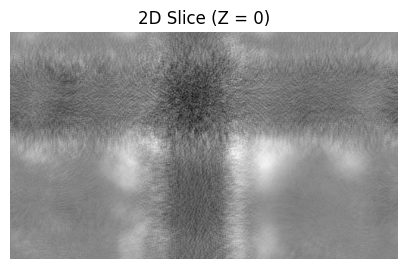

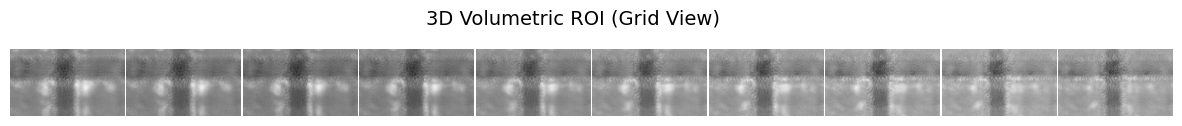

In [ ]:

image_path = './data_examples/example_tiff.tiff'

# Silence the harmless TIFF 'ResolutionUnit' warning to keep the console clean
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    
    # 1. Load an entire volume and inspect it
    print("--- Full Volume ---")
    img_full = BioImageBase.from_source(image_path)
    print(f"Shape: {img_full.shape} | Type: {type(img_full).__name__}")
    print(f"Original Channels format: {img_full.meta.get('layout')}")

    # 2. Load a 2D Region of Interest (ROI) and display it
    print("\n--- 2D ROI ---")
    roi_2d = BioImageBase.from_source(
        image_path, 
        channels="CYX", 
        ind_dict={'Z': 0, 'Y': slice(0, 300)} # First Z-slice, cropped Y
    )
    print(f"Shape: {roi_2d.shape}")

    # 3. Load a 3D ROI and display it as a grid
    print("\n--- 3D Volumetric ROI (Grid View) ---")
    roi_3d = BioImageBase.from_source(
        image_path, 
        channels="ZYX", 
        ind_dict={'Z': range(10), 'Y': slice(0, 300)} # First 10 Z-slices, cropped Y
    )
    print(f"Shape: {roi_3d.shape}")

# 4. Show the images using the built-in fastai/bioMONAI show method
roi_2d.show(title="2D Slice (Z = 0)", figsize=(5, 5))
plt.show() # Ensure the 2D plot renders cleanly before the grid

# A much shorter figsize (e.g., 15, 1.5) matches the 10:1 aspect ratio of the image strip
roi_3d.show(figsize=(15, 1.5)) 
plt.suptitle("3D Volumetric ROI (Grid View)", fontsize=14) 
plt.show()

In [ ]:
#| hide

def test_bioimagebase():
    dict_path = {'image': './data_examples/example_tiff.tiff'}
    source_path = './data_examples/example_tiff.tiff'
    
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        
        # Test __repr__ fallback
        repr_str = BioImageBase([1, 2, 3]).__repr__()
        test_eq(repr_str.startswith("BioImageBase"), True)
        
        # Test Dictionary Loader
        a_dict = BioImageBase.from_dict(dict_path.copy(), keys='image', channels="YX")
        test_eq(type(a_dict), dict)
        test_eq(type(a_dict['image']), BioImageBase)
        
        # Test Source Loader
        a_src = BioImageBase.from_source(source_path, channels="YX")
        test_eq(a_src.shape, a_src.meta['size_output'])
        test_eq(a_dict['image'].meta.keys(), a_src.meta.keys())
        
        # Test Pure MetaTensor Loaders
        mt_src = BioImageBase.get_loader()(source_path)
        test_eq(type(mt_src).__name__, "MetaTensor")
        
        mt_dict = BioImageBase.get_dict_loader(keys=['image'])(dict_path.copy())
        test_eq(type(mt_dict['image']).__name__, "MetaTensor")

    return "BioImageBase tests passed"

test_eq(test_bioimagebase(), "BioImageBase tests passed")

#### `BioImageBase` Class Attributes & Parameter Reference

| Method | Parameters | Description |
| :--- | :--- | :--- |
| **`from_source`** | `x`, `**kwargs` | Loads an image from a path directly into a `BioImageBase` instance. |
| **`from_dict`** | `x: dict`, `keys`, `**kwargs` | Loads images from dictionary paths, replacing them with `BioImageBase` instances in-place. |
| **`get_loader`** | `**kwargs` | Returns a callable that loads a source into a standard MONAI `MetaTensor`. |
| **`get_dict_loader`** | `**kwargs` | Returns a callable that processes a dictionary, loading target keys as `MetaTensor`s. |
| **`show`** | `ctx`, `figsize`, `title`, `**kwargs` | Visually renders the image tensor (automatically supports 2D slices and 3D grids). |

### BioImage
> `BioImage` is a specialization of `BioImageBase` specifically tailored for standard 2D and 3D biomedical images. By defaulting the channel layout to `"CYX"`, it automatically handles the squeezing of unnecessary dimensions and sets the stage for standard 2D/3D transformations.

* **Default Layout:** Sets `_channels = "CYX"` (Channels, Y, X) to streamline 2D image processing.
* **Direct Inheritance:** Inherits all powerful features from `BioImageBase` (like `from_source`, `from_dict`, and `show`).
* **Simplified Workflow:** Ideal for datasets where Z-stacks or time dimensions have already been reduced or are not required.

In [ ]:
#| export
class BioImage(BioImageBase):
    """
    Tensor-backed bioimage loaded from disk.
    """

    _channels = "CYX"


In [ ]:
show_doc(BioImage)

---

[source](https://github.com/deepCLEM/bioMONAI/blob/main/bioMONAI/data/core.py#L202){target="_blank" style="float:right; font-size:smaller"}

### BioImage

```python

def BioImage(
    x, affine:torch.Tensor | None=None, meta:dict | None=None, applied_operations:list | None=None,
    _args:VAR_POSITIONAL, _kwargs:VAR_KEYWORD
)->None:


```

*Tensor-backed bioimage loaded from disk.*

#### Example: Using BioImage to load a 2D Region of Interest


Type: BioImage
Shape: torch.Size([1, 300, 512])


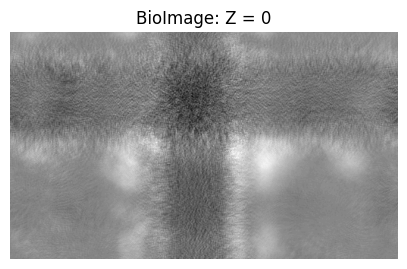

In [ ]:
image_path = './data_examples/example_tiff.tiff'

# Silence the harmless TIFF 'ResolutionUnit' warning to keep the console clean.
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    
    # Load a 2D Region of Interest (ROI) directly as a BioImage
    image_2d = BioImage.from_source(
        image_path, 
        ind_dict={'Z': 0, 'Y': slice(0, 300)} 
    )
    print(f"Type: {type(image_2d).__name__}")
    print(f"Shape: {image_2d.shape}")

# Display the 2D image
image_2d.show(title="BioImage: Z = 0", figsize=(5, 5))
plt.show()

In [ ]:
#| hide

def test_bioimage():
    image_path = './data_examples/example_tiff.tiff'
    
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        
        # 1. Test from_source loading
        img_2d = BioImage.from_source(image_path, ind_dict={'Z': 0, 'Y': slice(0, 300)})
        test_eq(type(img_2d), BioImage)
        test_eq(img_2d.shape, (1, 300, 512))
        
        # 2. Test pure loader returns MetaTensor
        img_2d_pure = BioImage.get_loader(ind_dict={'Z': 0, 'Y': slice(0, 300)})(image_path)
        test_eq(type(img_2d_pure).__name__, "MetaTensor")
        test_eq(img_2d_pure.shape, (1, 300, 512))

    return "BioImage tests passed"

test_eq(test_bioimage(), "BioImage tests passed")

#### `BioImage` Class Attributes & Parameter Reference

| Attribute | Type | Default | Description |
| :--- | :--- | :--- | :--- |
| **`_channels`** | `str` | `"CYX"` | The default channel layout used during loading. Automatically drops or squeezes unrequested dimensions like Z or T. |

*(Note: Initializes exactly like `BioImageBase`)*

### BioVolume
> `BioVolume` is a specialization of `BioImageBase` designed explicitly for handling 3D volumetric images. By defaulting to the `"CZYX"` channel layout, it ensures that volumetric data is parsed with the correct spatial dimensions, making it immediately ready for 3D spatial transforms.

* **Volumetric Focus:** Sets `_channels = "CZYX"` (Channels, Depth/Z, Height/Y, Width/X) to explicitly preserve depth.
* **Direct Inheritance:** Retains all the powerful loading and dictionary-handling capabilities of `BioImageBase`.
* **Volumetric Visualization:** Works out-of-the-box with the native `.show()` method to automatically render an optimal 2D representation of your 4D data tensor.

In [ ]:
#| export
class BioVolume(BioImageBase):
    """
    Tensor-backed volume loaded from disk.

    """

    _channels="CZYX"


In [ ]:
show_doc(BioVolume)

---

[source](https://github.com/deepCLEM/bioMONAI/blob/main/bioMONAI/data/core.py#L211){target="_blank" style="float:right; font-size:smaller"}

### BioVolume

```python

def BioVolume(
    x, affine:torch.Tensor | None=None, meta:dict | None=None, applied_operations:list | None=None,
    _args:VAR_POSITIONAL, _kwargs:VAR_KEYWORD
)->None:


```

*Tensor-backed volume loaded from disk.*

#### Example: Using BioVolume to load a 3D Region of Interest


Type: BioVolume
Shape: torch.Size([1, 10, 300, 512])


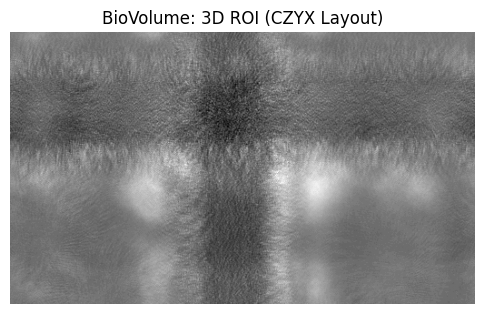

In [ ]:
image_path = './data_examples/example_tiff.tiff'

# Silence the harmless TIFF 'ResolutionUnit' warning to keep the console clean.
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    
    # Load a 3D Region of Interest (ROI) (e.g., the first 10 Z-slices, cropped Y)
    volume_3d = BioVolume.from_source(
        image_path, 
        ind_dict={'Z': range(10), 'Y': slice(0, 300)} 
    )
    print(f"Type: {type(volume_3d).__name__}")
    print(f"Shape: {volume_3d.shape}")

# Display the 3D volume representation
# Using a square figsize since CZYX renders as a single aggregated view
volume_3d.show(title="BioVolume: 3D ROI (CZYX Layout)", figsize=(6, 6))
plt.show()

In [ ]:
#| hide

def test_biovolume():
    image_path = './data_examples/example_tiff.tiff'
    
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        
        # Load from source
        vol_3d = BioVolume.from_source(image_path, ind_dict={'Z': range(10), 'Y': slice(0, 300)})
        test_eq(type(vol_3d), BioVolume)
        test_eq(vol_3d.shape, (1, 10, 300, 512))
        
        # Pure loader
        vol_3d_pure = BioVolume.get_loader(ind_dict={'Z': range(10), 'Y': slice(0, 300)}, channels="ZYX")(image_path)
        test_eq(type(vol_3d_pure).__name__, "MetaTensor")
        test_eq(vol_3d_pure.shape, (10, 300, 512))

    return "BioVolume tests passed"

test_eq(test_biovolume(), "BioVolume tests passed")

#### `BioVolume` Class Attributes & Parameter Reference

| Attribute | Type | Default | Description |
| :--- | :--- | :--- | :--- |
| **`_channels`** | `str` | `"CZYX"` | The default channel layout used during loading. Ensures the Z (depth) dimension is preserved for volumetric processing. |

*(Note: Initializes exactly like `BioImageBase`)*

In [ ]:
#| export
def _mip_transform(cls, img, layout):
    z_dim = layout.index("Z")

    mip = torchmax(img.as_tensor(), dim=z_dim).values

    meta = dict(img.meta)
    meta["layout"] = layout.replace("Z", "")
    meta["size_output"] = tuple(mip.shape)

    return cls(x=mip, meta=meta)

In [ ]:
#| hide

def test_mip_transform():
    # Dummy BioMIP class
    class DummyMIP(MetaTensor):
        pass
    
    # 3D tensor (C, Z, Y, X) with max at Z=4
    t = torcharange(500).reshape(1, 5, 10, 10).float()
    img_meta = MetaTensor(t, meta={"layout": "CZYX", "size_output": (1, 5, 10, 10)})
    
    # Apply MIP
    res = _mip_transform(DummyMIP, img_meta, "CZYX")
    
    # Verify Z is squashed
    test_eq(res.shape, (1, 10, 10))
    
    # Verify metadata
    test_eq(res.meta["layout"], "CYX")
    test_eq(res.meta["size_output"], (1, 10, 10))
    
    return "_mip_transform tests passed"

test_eq(test_mip_transform(), "_mip_transform tests passed")

### Maximum Intensity Projection (MIP)
> `BioMIP` represents a 3D image volume as a 2D image using Maximum Intensity Projection. It automatically squashes the Z-axis (depth) by taking the maximum voxel value along that dimension on the fly. 

* **Automatic Projection:** Inherits from `BioImageBase` but automatically applies a projection operation over the Z-axis during loading.
* **Visualization Ready:** Ideal for visualizing thick volumetric data (like fluorescent microscopy Z-stacks) in a flat, 2D format for quick assessments and presentations.
* **Metadata Updating:** Automatically updates the internal `.meta['layout']` dictionary from `"CZYX"` to `"CYX"` to accurately reflect the dimensionality reduction.

In [ ]:
#| export
class BioMIP(BioImageBase):
    """
    The `BioMIP` class represents a 3D image stack as a 2D image using maximum intensity projection. This is particularly useful for visualizing volumetric data in a 2D format, aiding in quick assessments and presentations.
    """
    
    _show_args = {"cmap": "gray"}
    _channels = "CZYX"
    _channel_modes = {1: "L", 3: "RGB", 4: "RGBA"}

    @classmethod
    def _get_layout(cls, img, kwargs):
        return img.meta.get("layout") or kwargs.get("channels") or cls._channels

    @classmethod
    def from_source(cls, x, keys=None, **kwargs):
        kwargs.setdefault("channels", cls._channels)

        is_dict_input = isinstance(x, dict) or (
            isinstance(x, Sequence)
            and x
            and isinstance(x[0], dict)
        )

        if is_dict_input:
            out = super(cls, cls).from_source(
                x,
                keys=keys,
                **kwargs,
            )

            if keys is None:
                keys = []

            if isinstance(keys, str):
                keys = [keys]

            layout = kwargs.get("channels")

            for key in keys:
                img = out[key]
                out[key] = _mip_transform(cls, img, layout)

            return out

        img = super(cls, cls).from_source(x, **kwargs)

        layout = kwargs.get("channels")

        return _mip_transform(cls, img, layout)


In [ ]:
show_doc(BioMIP)

---

[source](https://github.com/deepCLEM/bioMONAI/blob/main/bioMONAI/data/core.py#L233){target="_blank" style="float:right; font-size:smaller"}

### BioMIP

```python

def BioMIP(
    x, affine:torch.Tensor | None=None, meta:dict | None=None, applied_operations:list | None=None,
    _args:VAR_POSITIONAL, _kwargs:VAR_KEYWORD
)->None:


```

*The `BioMIP` class represents a 3D image stack as a 2D image using maximum intensity projection. This is particularly useful for visualizing volumetric data in a 2D format, aiding in quick assessments and presentations.*

#### Example: Generating a Maximum Intensity Projection from a 3D volume


Type: BioMIP
Projected Shape: torch.Size([1, 512, 512])
Final Layout: CYX


<Axes: title={'center': 'Maximum Intensity Projection'}>

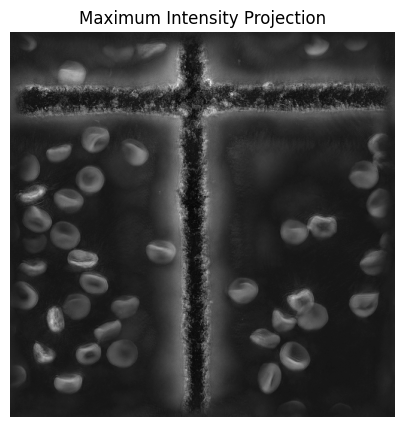

In [ ]:
image_path = './data_examples/example_tiff.tiff'

# Silence the harmless TIFF 'ResolutionUnit' warning to keep the console clean.
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    
    # Load the volume and automatically project it to 2D
    image_mip = BioMIP.from_source(image_path)
    print(f"Type: {type(image_mip).__name__}")
    print(f"Projected Shape: {image_mip.shape}")
    print(f"Final Layout: {image_mip.meta.get('layout')}")

# Display the resulting 2D projection
image_mip.show(title="Maximum Intensity Projection", figsize=(5, 5))

In [ ]:
#| hide

def test_biomip():
    image_path = './data_examples/example_tiff.tiff'
    
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        
        # Load MIP (original: 1x96x512x512)
        img_mip = BioMIP.from_source(image_path)
        
        # Verify Z is squashed
        test_eq(type(img_mip), BioMIP)
        test_eq(img_mip.shape, (1, 512, 512))
        test_eq(img_mip.meta['layout'], "CYX")

    return "BioMIP tests passed"

test_eq(test_biomip(), "BioMIP tests passed")

#### `BioMIP` Class Attributes & Parameter Reference

| Attribute | Type | Default | Description |
| :--- | :--- | :--- | :--- |
| **`_channels`** | `str` | `"CZYX"` | The expected initial layout before the Z-axis is squashed. |
| **`_show_args`** | `dict` | `{"cmap": "gray"}` | Default visualization styling applied when rendering the 2D projection. |

*(Note: Inherits loading methods like `from_source` from `BioImageBase`, automatically applying the projection step)*

### BioVideo
> `BioVideo` is a specialization of `BioImageBase` designed specifically for temporal or video data. By setting the default channel layout to `"CTYX"`, it ensures that time-series images (like live-cell imaging or standard video files) are parsed correctly for spatiotemporal transforms.

* **Temporal Focus:** Sets `_channels = "CTYX"` (Channels, Time/Frames, Height/Y, Width/X) to explicitly preserve the sequence of frames.
* **Direct Inheritance:** Retains all loading, dictionary-handling, and metadata-tracking capabilities of `BioImageBase`.
* **Video Processing:** Ideal for pipelines dealing with live-cell imaging, behavioral videos, or dynamic medical imaging (e.g., cine MRI).

In [ ]:
#| export
class BioVideo(BioImageBase):
    """
    Tensor-backed video loaded from disk.

    This is the class that:
    - uses image_reader
    - handles transforms
    - returns MetaTensor-backed images
    """

    _channels="CTYX"
    

In [ ]:
show_doc(BioVideo)

---

[source](https://github.com/deepCLEM/bioMONAI/blob/main/bioMONAI/data/core.py#L285){target="_blank" style="float:right; font-size:smaller"}

### BioVideo

```python

def BioVideo(
    x, affine:torch.Tensor | None=None, meta:dict | None=None, applied_operations:list | None=None,
    _args:VAR_POSITIONAL, _kwargs:VAR_KEYWORD
)->None:


```

*Tensor-backed video loaded from disk.*

This is the class that:
- uses image_reader
- handles transforms
- returns MetaTensor-backed images

#### Example: Loading temporal/video data using BioVideo


Type:   BioVideo
Shape:  torch.Size([1, 1, 512, 512])
Layout: CTYX


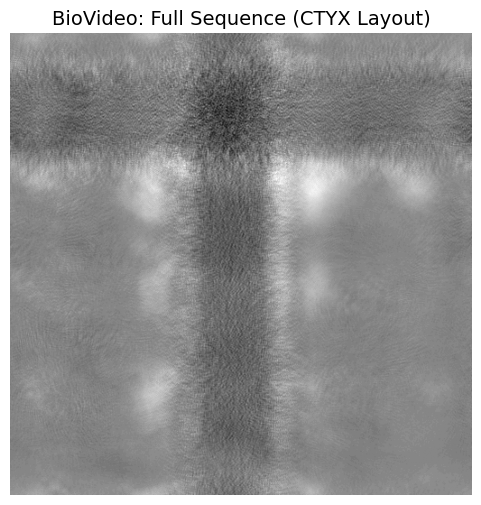

In [ ]:
image_path = './data_examples/example_tiff.tiff'

with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    
    # Load data as a temporal sequence
    video_seq = BioVideo.from_source(image_path)
    print(f"Type:   {type(video_seq).__name__}")
    print(f"Shape:  {video_seq.shape}")
    print(f"Layout: {video_seq.meta.get('layout')}")

# Display the 4D video tensor representation
video_seq.show(figsize=(6, 6))
plt.title("BioVideo: Full Sequence (CTYX Layout)", fontsize=14)
plt.show()

In [ ]:
#| hide

def test_biovideo():
    image_path = './data_examples/example_tiff.tiff'
    
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        
        # Load
        vid = BioVideo.from_source(image_path)
        
        # Verify
        test_eq(type(vid), BioVideo)
        test_eq(vid.meta['layout'], "CTYX")
        test_eq(vid.ndim, 4)

    return "BioVideo tests passed"

test_eq(test_biovideo(), "BioVideo tests passed")

#### `BioVideo` Class Attributes & Parameter Reference

| Attribute | Type | Default | Description |
| :--- | :--- | :--- | :--- |
| **`_channels`** | `str` | `"CTYX"` | The default channel layout used during loading. Ensures the T (time/frames) dimension is parsed and preserved. |

*(Note: Initializes exactly like `BioImageBase`)*

### BioMultiChannel
> `BioMultiChannel` is a specialized class designed for handling multi-channel 2D and 3D images, assuming a `"CZYX"` layout by default. 

* **Automatic Flattening:** Automatically merges the Channel (C) and Depth (Z) dimensions (`merge_cd=True`) upon loading.
* **Microscopy Ready:** Particularly useful in microscopy, where multi-channel 3D stacks are often flattened or interleaved into a single sequential axis to simplify downstream processing.
* **Specialized Visualization:** Overrides the base `.show()` method to use `show_multichannel`, expertly handling the rendering of composite or interleaved channel grids.

In [ ]:
#| export
class BioMultiChannel(BioImageBase):
    """
    Multi-channel 2D/3D image assuming CZYX layout.
    """

    @classmethod
    def _apply_mip(cls, tensor, merge_cd, interleaved, **kwargs):
            layout = (
                kwargs.get("layout")
                or getattr(tensor, "meta", {}).get("layout")
                or cls._channels
            )

            if not merge_cd:
                if hasattr(tensor, "meta"):
                    tensor.meta["layout"] = layout
                    tensor.meta["size_output"] = tuple(tensor.shape)
                return tensor

            if layout is None or "C" not in layout or "Z" not in layout:
                raise ValueError(
                    f"BioMultiChannel merge_cd requires C and Z axes, got {layout!r}"
                )

            c_dim = layout.index("C")
            z_dim = layout.index("Z")

            c = tensor.shape[c_dim]
            d = tensor.shape[z_dim]

            spatial_dims = [i for i in range(tensor.ndim) if i not in (c_dim, z_dim)]

            if interleaved:
                permute_dims = [z_dim, c_dim, *spatial_dims]
            else:
                permute_dims = [c_dim, z_dim, *spatial_dims]

            tensor = tensor.permute(*permute_dims)
            tensor = tensor.reshape(c * d, *tensor.shape[2:])

            output_layout = layout.replace("Z", "")

            if hasattr(tensor, "meta"):
                tensor.meta["layout"] = output_layout
                tensor.meta["size_output"] = tuple(tensor.shape)

            return tensor
    
    @classmethod
    def from_source(
        cls,
        x: PathLike | Sequence[PathLike] | torchTensor,
        keys=None,
        merge_cd: bool = True,
        interleaved: bool = True,
        **kwargs,
    ):
        kwargs.setdefault("channels", cls._channels)

        out = super().from_source(x, keys=keys, **kwargs)

        if isinstance(out, dict):
            return {k: cls._apply_mip(v, merge_cd=merge_cd, interleaved=interleaved, **kwargs) for k, v in out.items()}

        return cls._apply_mip(out, merge_cd=merge_cd, interleaved=interleaved, **kwargs)

    def show(self, ctx=None, **kwargs):
        return show_multichannel(self, ctx=ctx, **merge(self._show_args, kwargs))



In [ ]:
show_doc(BioMultiChannel)

---

[source](https://github.com/deepCLEM/bioMONAI/blob/main/bioMONAI/data/core.py#L299){target="_blank" style="float:right; font-size:smaller"}

### BioMultiChannel

```python

def BioMultiChannel(
    x, affine:torch.Tensor | None=None, meta:dict | None=None, applied_operations:list | None=None,
    _args:VAR_POSITIONAL, _kwargs:VAR_KEYWORD
)->None:


```

*Multi-channel 2D/3D image assuming CZYX layout.*

#### Example: Loading and flattening a multi-channel 3D stack


Type:   BioMultiChannel
Shape:  torch.Size([5, 300, 512])
Layout: CYX


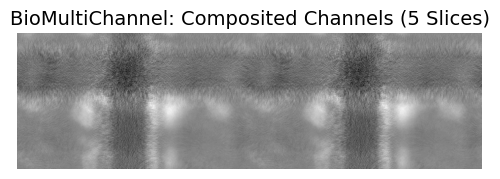

In [ ]:
image_path = './data_examples/example_tiff.tiff'

with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    
    # Load a subset of the image (First 5 Z-slices).
    # BioMultiChannel will automatically merge the C and Z-depth dimensions.
    image_mlt = BioMultiChannel.from_source(
        image_path,
        ind_dict={'Z': range(5), 'Y': slice(0, 300)}
    )
    
    print(f"Type:   {type(image_mlt).__name__}")
    print(f"Shape:  {image_mlt.shape}")
    print(f"Layout: {image_mlt.meta.get('layout')}")

# Display the composited multi-channel image
# Using a square figsize since show_multichannel overlays them into a single view
image_mlt.show(figsize=(6, 6))
plt.title("BioMultiChannel: Composited Channels (5 Slices)", fontsize=14)
plt.show()

In [ ]:
#| hide

def test_biomultichannel():
    image_path = './data_examples/example_tiff.tiff'
    
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        
        # Load
        img_mlt = BioMultiChannel.from_source(image_path)
        
        # Verify shape (C=1, Z=96 -> merged C=96)
        test_eq(type(img_mlt), BioMultiChannel)
        test_eq(tuple(img_mlt.shape), (96, 512, 512))
        test_eq(img_mlt.meta['layout'], "CYX")

    return "BioMultiChannel tests passed"

test_eq(test_biomultichannel(), "BioMultiChannel tests passed")

#### `BioMultiChannel` Class Attributes & Parameter Reference

| Attribute / Parameter | Type | Default | Description |
| :--- | :--- | :--- | :--- |
| **`_channels`** | `str` | `"CZYX"` | The expected initial layout before merging operations. |
| **`merge_cd`** | `bool` | `True` | If `True`, flattens the Z (depth) dimension into the C (channel) dimension during loading. |
| **`interleaved`** | `bool` | `True` | Determines the permutation order when merging. If `True`, channels and depths are interleaved sequentially. |

### Categorical Labels
> `BioLabel` is a specialized data class for handling categorical data, such as classification targets. Built on top of fastai's `Categorize` transform, it automatically manages vocabulary creation, handles sorting, and seamlessly maps textual labels to integer IDs (and vice versa).

* **Vocabulary Management:** Automatically builds, sorts, and maintains a unique vocabulary from your dataset.
* **fastai Integration:** Leverages the native `Categorize` transform, ensuring full compatibility with standard deep learning pipelines.
* **Flexible Loading:** Fully supports both standard sequence and dictionary-based data pipelines (`from_source` and `from_dict`).

In [ ]:
#| export
class BioLabel(BioDataClass):
    """
    Data class for Categorical data.

    """

    _keys = ['label']
    _vocab = None
    _sort = True
    _add_na = False

    # --------------------------------------------------
    # LOADING
    # --------------------------------------------------
    @classmethod
    def from_source(cls, x, **kwargs):
        cat = cls.get_label(**kwargs)
        return cat(x)
    
    @classmethod
    def from_dict(cls, x:dict, keys:str|Iterable[str]=None, **kwargs):
        cat = cls.get_dict_label(keys=keys, **kwargs)
        return cat(x)
    
    # --------------------------------------------------
    # MONAI INTEGRATION
    # --------------------------------------------------
    @classmethod
    def get_label(cls,**kwargs) -> Callable:

        vocab = kwargs.get('vocab', cls._vocab)
        sort = kwargs.get('sort', cls._sort)
        add_na = kwargs.get('add_na', cls._add_na)

        cat = Categorize(vocab=vocab, sort=sort, add_na=add_na)

        return cat

    @classmethod
    def get_dict_label(cls, **kwargs) -> Callable:

        vocab = kwargs.get('vocab', cls._vocab)
        sort = kwargs.get('sort', cls._sort)
        add_na = kwargs.get('add_na', cls._add_na)
        keys = kwargs.get("keys", cls._keys)

        if isinstance(keys, str):
            keys = [keys]

        cat = Categorize(vocab=vocab, sort=sort, add_na=add_na)

        def _load_dict(data: dict):
            out = data.copy()
            for key in keys:
                out[key] = cat(data[key])
            return out

        # attach attrs
        _load_dict.vocab = vocab
        _load_dict.sort = sort
        _load_dict.add_na = add_na
        _load_dict.keys = keys
        _load_dict.cat = cat

        return _load_dict

    
    

In [ ]:
show_doc(BioLabel)

---

[source](https://github.com/deepCLEM/bioMONAI/blob/main/bioMONAI/data/core.py#L371){target="_blank" style="float:right; font-size:smaller"}

### BioLabel

```python

def BioLabel(
    x, affine:torch.Tensor | None=None, meta:dict | None=None, applied_operations:list | None=None,
    _args:VAR_POSITIONAL, _kwargs:VAR_KEYWORD
)->None:


```

*Data class for Categorical data.*

#### Example: Encoding and decoding categorical labels using BioLabel


In [ ]:
# 1. Initialize the label encoder with a specific vocabulary
# (Note: duplicates are removed and the vocabulary is sorted alphabetically by default)
label_encoder = BioLabel.get_label(vocab=['malignant', 'benign', 'benign', 'normal'])

print(f"Generated Vocabulary: {list(label_encoder.vocab)}")

# 2. Encode a string label into an integer ID
encoded_id = label_encoder('malignant')
print(f"Encoded ID for 'malignant': {encoded_id}")

# 3. Decode the integer ID back to the original string
decoded_label = label_encoder.decode(encoded_id)
print(f"Decoded Label for ID {encoded_id}: {decoded_label}")

Generated Vocabulary: ['benign', 'malignant', 'normal']
Encoded ID for 'malignant': TensorCategory(1)
Decoded Label for ID TensorCategory(1): malignant


In [ ]:
#| hide

def test_biolabel():
    # Setup
    t = BioLabel.get_label(vocab=['b', 'a', 'a', 'a', 'c'])
    
    # Check vocab sorting and uniqueness
    test_eq(list(t.vocab), ['a', 'b', 'c'])
    
    # Check decoding
    test_eq(t.decode(1), 'b')
    
    # Check encoding
    test_eq(t('b'), 1)
    
    # Verify method absence
    test_eq(hasattr(BioLabel, "get_loader"), False)
    
    # Check dict loader
    dict_loader = BioLabel.get_dict_label(keys=['label'], vocab=['a', 'b'])
    res = dict_loader({'label': 'a', 'other': 'keep'})
    test_eq(res['label'], 0)
    test_eq(res['other'], 'keep')

    return "BioLabel tests passed"

test_eq(test_biolabel(), "BioLabel tests passed")

#### `BioLabel` Class Attributes & Parameter Reference

| Attribute / Parameter | Type | Default | Description |
| :--- | :--- | :--- | :--- |
| **`_keys`** | `list` | `['label']` | The default dictionary key used when parsing labels from a dictionary. |
| **`_vocab`** | `list \| None` | `None` | The explicit vocabulary list. If `None`, it is inferred from the data. |
| **`_sort`** | `bool` | `True` | Whether to automatically sort the vocabulary alphabetically. |
| **`_add_na`** | `bool` | `False` | Whether to add an `#na#` (Not Available) token to the vocabulary to handle missing data. |

In [ ]:
#| hide
import nbdev; nbdev.nbdev_export()